In [55]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style('darkgrid')

Dataset loaded successfully.
Index(['Hour', 'Result'], dtype='object')
   Hour Result
0     5   Fail
1     3   Fail
2     1   Fail
3     5   Fail
4     7   Pass


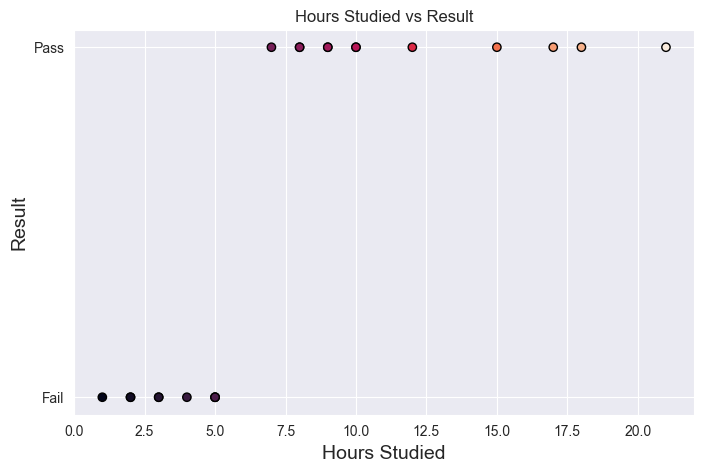

In [63]:
#Load the dataset
df=pd.read_csv('pass.csv')
print("Dataset loaded successfully.")
print(df.columns)
print(df.head())


#Visualize the data
plt.figure(figsize=(8,5))
# plt.scatter(df['Result'], df['Hour'], cmap='bwr', edgecolor='k', s=100)
plt.scatter(df['Hour'], df['Result'],c=df['Hour'], edgecolor='k')
plt.xlabel('Hours Studied', fontsize=14)
plt.ylabel('Result', fontsize=14)
plt.title('Hours Studied vs Result')
plt.show()

In [56]:
x=df['Hour']
y=df['Result']
model=LogisticRegression()
model.fit(x.values.reshape(-1,1),y)
print("Model trained successfully.")

Model trained successfully.


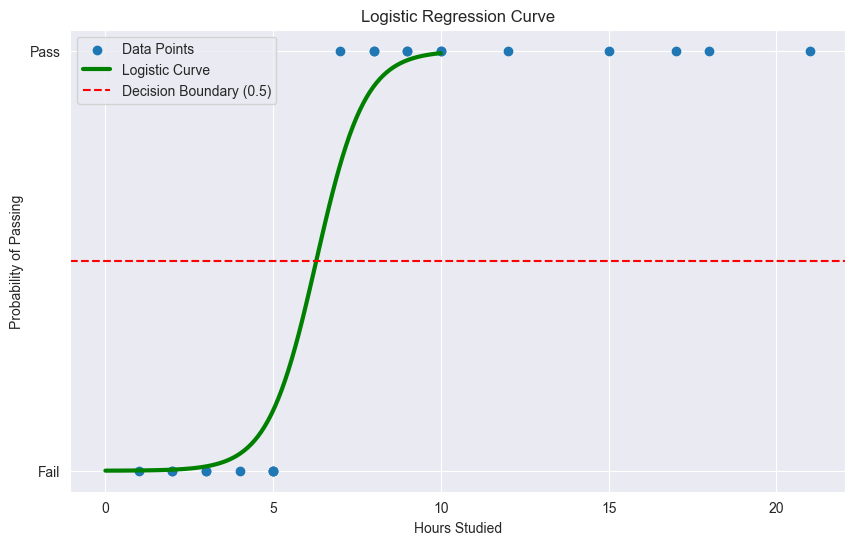

In [64]:
#Visualize the sigmoid curve
plt.figure(figsize=(10,6))
plt.scatter(df['Hour'], df['Result'],label='Data Points')

#Generate a range of value for the curve
x_test_range=np.linspace(0,10,100).reshape(-1,1)
y_prob_range=model.predict_proba(x_test_range)[:,1]

plt.plot(x_test_range, y_prob_range, color='green', linewidth=3, label='Logistic Curve')
plt.axhline(0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression Curve')
plt.legend()
plt.show()

In [73]:
try:
    #get user input
    user_input=float(input("Enter the number of hours studied: "))
    #Prepare the input for prediction
    X_user=np.array([[user_input]])

    #Make the prediction
    prediction = model.predict(X_user)[0]
    probability = model.predict_proba(X_user)[0][1]
    #Output the result
    if prediction == 1:
        print(f"Predicted Result: Pass")
        print(f"confidence: {probability*100:.2f}%")
    else:
        print(f"Predicted Result: Fail")
        print(f"confidence: {(1-probability)*100:.2f}%")
except ValueError:
    print("Invalid input. Please enter a numeric value for hours studied.")

Predicted Result: Fail
confidence: 0.00%
